FINAL FORECASTING NOTEBOOK - HISTGRADIENTBOOSTING (NO DATA LEAKAGE)

✅ 2023 data shape: (17547, 365)
✅ 2024 data shape: (17547, 366)
✅ Cluster assignments shape: (17547, 15)
✅ Valid households after alignment: 17,547
✅ Clusters found: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
✅ 2023 dates: 2023-01-01 to 2023-12-31
✅ 2024 dates: 2024-01-01 to 2024-12-31

COMPUTING HOUSEHOLD-LEVEL STATIC FEATURES (2023 ONLY)
✅ Household stats shape: (17547, 11)
✅ Number of features: 41

PREPARING TRAINING DATA (2023 ONLY)


Creating training features: 100%|█████████| 17547/17547 [11:37<00:00, 25.16it/s]



✅ Feature creation finished in 838.1 seconds
✅ Training rows: 5,878,245
✅ X_train_all shape: (5878245, 41)
✅ y_train_all shape: (5878245,)

TRAINING GLOBAL HISTGRADIENTBOOSTING MODEL
✅ Global model trained in 84.5 seconds
✅ Saved: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/outputs/forecasting/final_histgb_global_model.pkl

TRAINING CLUSTER-SPECIFIC HISTGRADIENTBOOSTING MODELS

Cluster 0
  Training rows: 1,920,555
  ✅ Cluster model trained and saved: final_histgb_cluster_0_model.pkl

Cluster 1
  Training rows: 3,872,935
  ✅ Cluster model trained and saved: final_histgb_cluster_1_model.pkl

Cluster 2
  Training rows: 28,140
  ⚠️ Using global fallback

Cluster 3
  Training rows: 335
  ⚠️ Using global fallback

Cluster 4
  Training rows: 56,280
  ⚠️ Using global fallback

Households per cluster:
  Cluster 0: 5,733
  Cluster 1: 11,561
  Cluster 2: 84
  Cluster 3: 1
  Cluster 4: 168

BATCHED RECURSIVE FORECASTING FOR 2024 (NO DATA LEAKAGE)

Processi

Evaluating: 100%|████████████████████████| 17547/17547 [00:22<00:00, 791.17it/s]



FORECASTING RESULTS (FINAL, NO DATA LEAKAGE)

Model                        MAE          RMSE         R²          
----------------------------------------------------------------------
Global HistGB                3.8947       4.9119       0.5745      
Cluster HistGB (Final)       3.7443       4.8000       0.5666      

📈 Improvement in MAE: +3.86%

PER-CLUSTER MAE

Cluster 0:
  Households: 5,733
  MAE: 6.4462

Cluster 1:
  Households: 11,561
  MAE: 2.4580

Cluster 2:
  Households: 84
  MAE: 1.9913

Cluster 3:
  Households: 1
  MAE: 2.3147

Cluster 4:
  Households: 168
  MAE: 0.9469


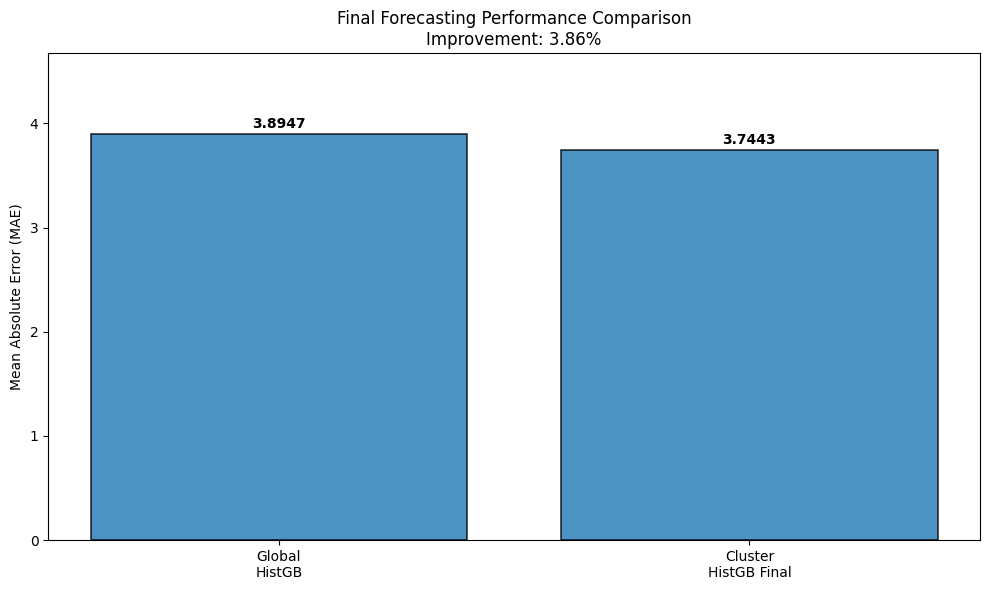

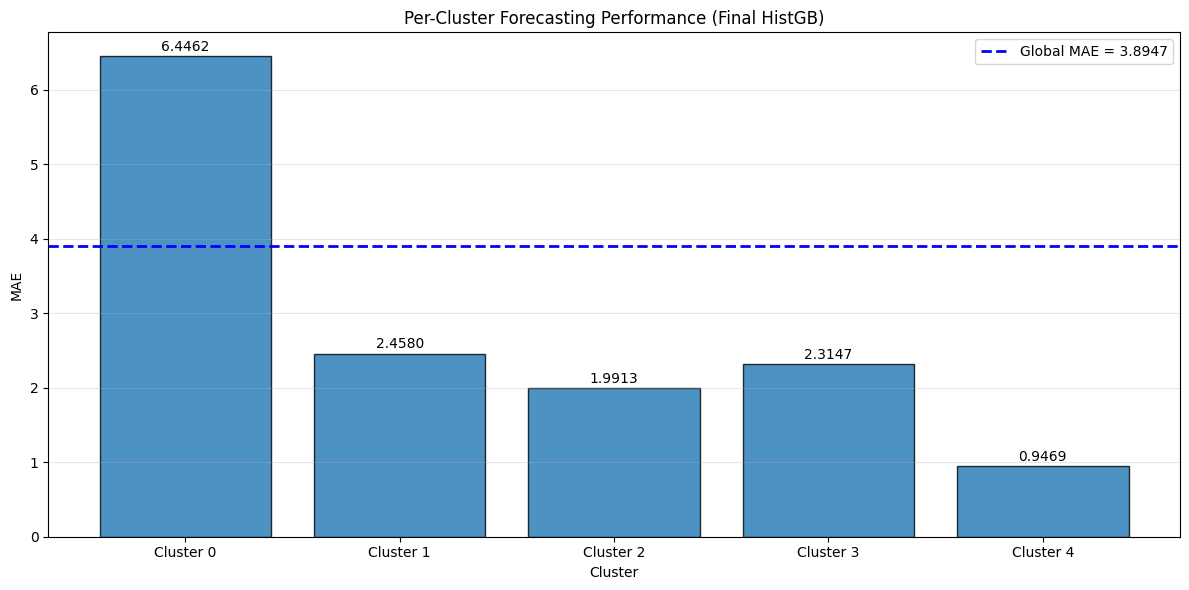

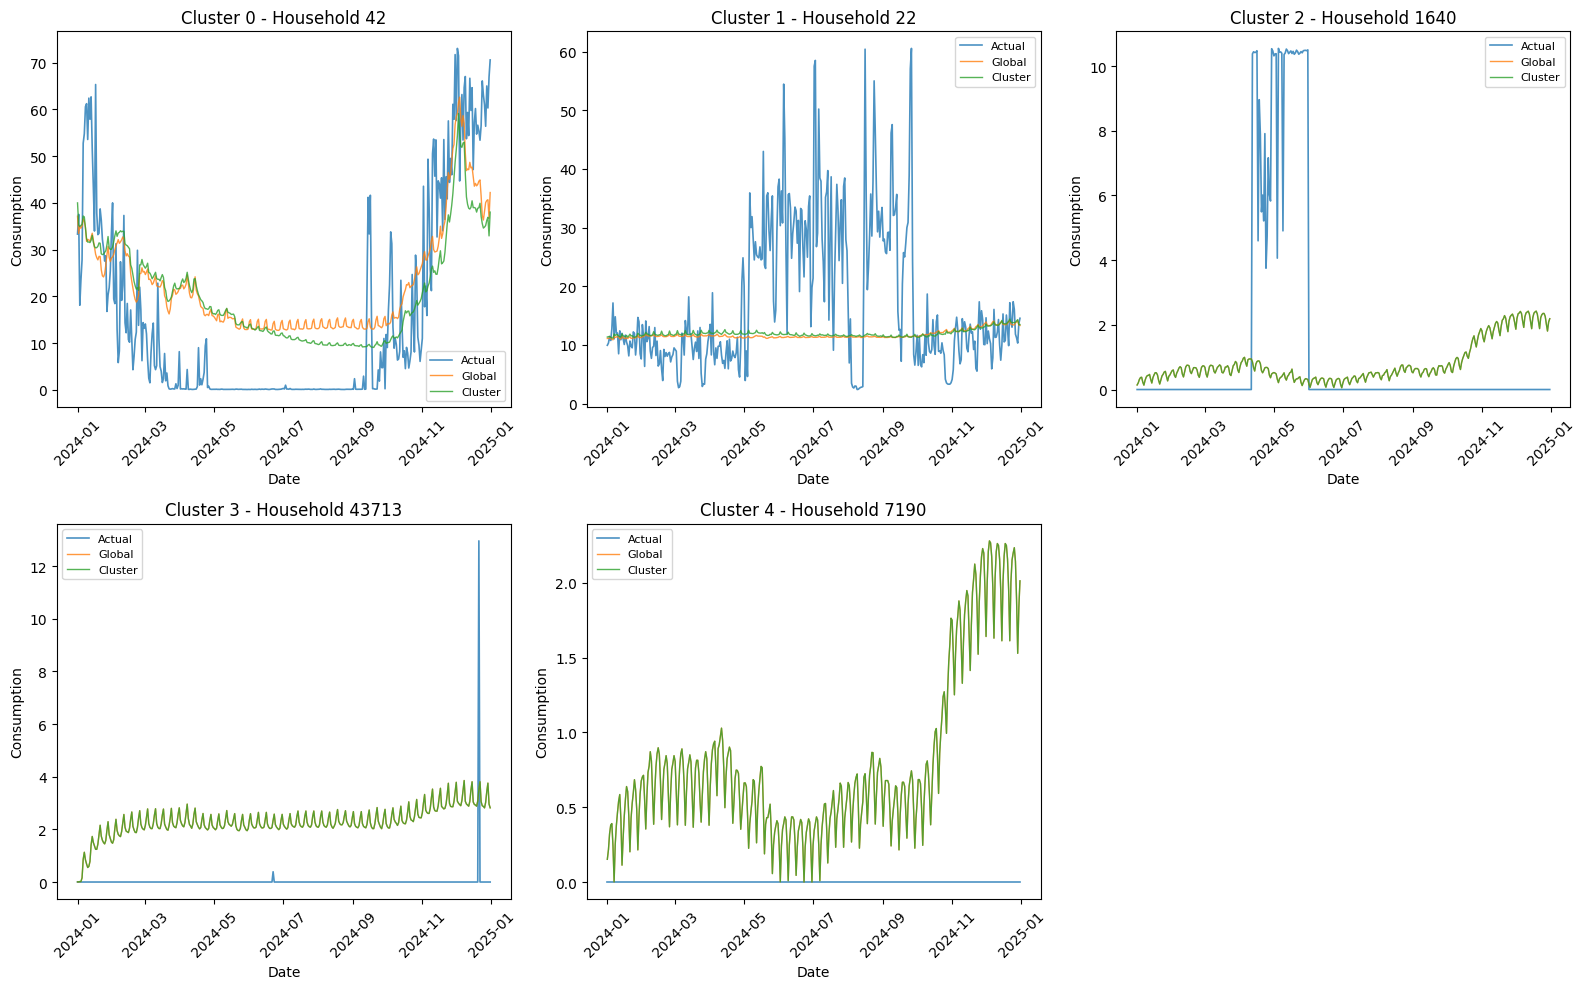


FORECASTING COMPLETE

✅ Results saved to: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/outputs/forecasting
   - final_histgb_forecasting_results_no_leakage.csv
   - final_histgb_per_cluster_results_no_leakage.csv
   - final_histgb_global_predictions_recursive.csv
   - final_histgb_cluster_predictions_recursive.csv

✅ Figures saved to: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/ProjectWORK/outputs/figures

FINAL SUMMARY - HISTGB IMPROVED VERSION

Training Data: 2023 only
Evaluation Data: 2024 only
Households: 17,547

Prediction Method:
- Recursive forecasting
- Batched prediction by cluster
- No actual 2024 values used during forecasting

Features:
- lag features
- rolling statistics
- rolling min/max
- calendar features
- cyclical features
- household-level static 2023 features

Global HistGB:
  MAE  = 3.8947
  RMSE = 4.9119
  R²   = 0.5745

Cluster HistGB Final:
  MAE  = 3.7443
  RMSE = 4.8000
  R²   = 0.5666

Impr

In [9]:
# %% [markdown]
# # Final Forecasting Notebook - HistGradientBoosting (Improved MAE, No Data Leakage)
# ## KDDSS 2026 Project
#
# Final design:
# - Global baseline model
# - Cluster-based forecasting model
# - HistGradientBoostingRegressor
# - Batched recursive forecasting
# - Strict no leakage:
#   * training uses only 2023
#   * 2024 used only for evaluation
#
# Improvements added:
# - household-level static 2023 features
# - extra lags: 5, 10, 28
# - rolling min/max statistics
# - better temporal features
#
# Output:
# - evaluation metrics
# - per-cluster MAE
# - predictions CSV files
# - comparison figures

# %% [markdown]
# ## 1. Setup and Imports

# %%
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tqdm import tqdm

warnings.filterwarnings("ignore")

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.config import (
    RAW_DATA_DIR,
    CLUSTERING_OUTPUT_DIR,
    FORECASTING_OUTPUT_DIR,
    FIGURES_DIR,
    RANDOM_SEED
)

np.random.seed(RANDOM_SEED)

print("=" * 90)
print("FINAL FORECASTING NOTEBOOK - HISTGRADIENTBOOSTING (NO DATA LEAKAGE)")
print("=" * 90)

# %% [markdown]
# ## 2. Load Data

# %%
df_2023 = pd.read_csv(RAW_DATA_DIR / "sample_23.csv", index_col=0)
df_2024 = pd.read_csv(RAW_DATA_DIR / "sample_24.csv", index_col=0)
cluster_assignments = pd.read_csv(CLUSTERING_OUTPUT_DIR / "cluster_assignments_features.csv")

print(f"\n✅ 2023 data shape: {df_2023.shape}")
print(f"✅ 2024 data shape: {df_2024.shape}")
print(f"✅ Cluster assignments shape: {cluster_assignments.shape}")

# Household -> cluster mapping
id_to_cluster = dict(zip(cluster_assignments["ID"], cluster_assignments["cluster"]))

# Keep only households that exist in clustering assignments
valid_households = [hid for hid in df_2023.index if hid in id_to_cluster]
df_2023 = df_2023.loc[valid_households]
df_2024 = df_2024.loc[df_2024.index.intersection(valid_households)]

clusters = sorted(cluster_assignments["cluster"].unique())

print(f"✅ Valid households after alignment: {len(valid_households):,}")
print(f"✅ Clusters found: {clusters}")

# %% [markdown]
# ## 3. Dates and Basic Setup

# %%
dates_2023 = pd.date_range(start="2023-01-01", periods=365, freq="D")
dates_2024 = pd.date_range(start="2024-01-01", periods=366, freq="D")

print(f"✅ 2023 dates: {dates_2023.min().date()} to {dates_2023.max().date()}")
print(f"✅ 2024 dates: {dates_2024.min().date()} to {dates_2024.max().date()}")

# %% [markdown]
# ## 4. Household-Level Static Features from 2023 Only
#
# These are safe because they use only 2023 data.
# They help the model understand the overall behavior of each household.

# %%
print("\n" + "=" * 90)
print("COMPUTING HOUSEHOLD-LEVEL STATIC FEATURES (2023 ONLY)")
print("=" * 90)

# weekday/weekend masks for 2023
dow_2023 = pd.Series(dates_2023.dayofweek, index=df_2023.columns)
weekday_cols_2023 = dow_2023[dow_2023 < 5].index
weekend_cols_2023 = dow_2023[dow_2023 >= 5].index

# Convert column labels if needed
weekday_positions_2023 = [df_2023.columns.get_loc(c) for c in weekday_cols_2023]
weekend_positions_2023 = [df_2023.columns.get_loc(c) for c in weekend_cols_2023]

weekday_data_2023 = df_2023.iloc[:, weekday_positions_2023]
weekend_data_2023 = df_2023.iloc[:, weekend_positions_2023]

df_household_stats = pd.DataFrame({
    "household_id": df_2023.index,
    "mean_365": df_2023.mean(axis=1).values,
    "std_365": df_2023.std(axis=1).values,
    "max_365": df_2023.max(axis=1).values,
    "min_365": df_2023.min(axis=1).values,
    "median_365": df_2023.median(axis=1).values,
    "weekday_mean": weekday_data_2023.mean(axis=1).values,
    "weekend_mean": weekend_data_2023.mean(axis=1).values
})

df_household_stats["weekend_ratio"] = (
    df_household_stats["weekend_mean"] / (df_household_stats["weekday_mean"] + 1e-6)
)
df_household_stats["range_365"] = df_household_stats["max_365"] - df_household_stats["min_365"]
df_household_stats["cv_365"] = df_household_stats["std_365"] / (df_household_stats["mean_365"] + 1e-6)

print(f"✅ Household stats shape: {df_household_stats.shape}")

# Keep a fast lookup table aligned by household_id
df_household_stats = df_household_stats.set_index("household_id")

# %% [markdown]
# ## 5. Define Feature Columns

# %%
FEATURE_COLS = [
    # Lags
    "lag_1", "lag_2", "lag_3", "lag_5", "lag_7", "lag_10",
    "lag_14", "lag_21", "lag_28", "lag_30",

    # Rolling means / stds
    "rolling_mean_7", "rolling_std_7",
    "rolling_mean_14", "rolling_std_14",
    "rolling_mean_30", "rolling_std_30",

    # Rolling min / max
    "rolling_min_7", "rolling_max_7",
    "rolling_min_30", "rolling_max_30",

    # Exponential weighted feature
    "ewm_7",

    # Calendar features
    "day_of_week", "month", "day_of_month",
    "week_of_year", "quarter", "is_weekend",

    # Cyclical encodings
    "doy_sin", "doy_cos", "dow_sin", "dow_cos",

    # Household-level static features from 2023
    "mean_365", "std_365", "max_365", "min_365", "median_365",
    "weekday_mean", "weekend_mean", "weekend_ratio",
    "range_365", "cv_365"
]

print(f"✅ Number of features: {len(FEATURE_COLS)}")

# %% [markdown]
# ## 6. Create Training Features (2023 Only, No Leakage)

# %%
def create_features_for_training(df, dates, household_stats):
    """
    Create supervised training rows using only 2023 data.
    For target day t, all lag/statistics use only values before t.
    """
    rows = []

    weights = np.exp(np.linspace(-1, 0, 7)).astype(np.float32)
    weights /= weights.sum()

    for household_id in tqdm(df.index, desc="Creating training features"):
        series = df.loc[household_id].values.astype(np.float32)
        static = household_stats.loc[household_id]

        for day in range(30, len(series)):
            hist = series[:day]
            current_date = dates[day]

            rows.append({
                "household_id": household_id,

                # Lags
                "lag_1": hist[-1],
                "lag_2": hist[-2],
                "lag_3": hist[-3],
                "lag_5": hist[-5],
                "lag_7": hist[-7],
                "lag_10": hist[-10],
                "lag_14": hist[-14],
                "lag_21": hist[-21],
                "lag_28": hist[-28],
                "lag_30": hist[-30],

                # Rolling stats
                "rolling_mean_7": np.mean(hist[-7:]),
                "rolling_std_7": np.std(hist[-7:]),
                "rolling_mean_14": np.mean(hist[-14:]),
                "rolling_std_14": np.std(hist[-14:]),
                "rolling_mean_30": np.mean(hist[-30:]),
                "rolling_std_30": np.std(hist[-30:]),

                # Rolling min/max
                "rolling_min_7": np.min(hist[-7:]),
                "rolling_max_7": np.max(hist[-7:]),
                "rolling_min_30": np.min(hist[-30:]),
                "rolling_max_30": np.max(hist[-30:]),

                # EWM
                "ewm_7": np.sum(hist[-7:] * weights),

                # Calendar
                "day_of_week": current_date.dayofweek,
                "month": current_date.month,
                "day_of_month": current_date.day,
                "week_of_year": int(current_date.isocalendar().week),
                "quarter": current_date.quarter,
                "is_weekend": 1 if current_date.dayofweek >= 5 else 0,

                # Cyclical
                "doy_sin": np.sin(2 * np.pi * current_date.dayofyear / 365),
                "doy_cos": np.cos(2 * np.pi * current_date.dayofyear / 365),
                "dow_sin": np.sin(2 * np.pi * current_date.dayofweek / 7),
                "dow_cos": np.cos(2 * np.pi * current_date.dayofweek / 7),

                # Household static features
                "mean_365": static["mean_365"],
                "std_365": static["std_365"],
                "max_365": static["max_365"],
                "min_365": static["min_365"],
                "median_365": static["median_365"],
                "weekday_mean": static["weekday_mean"],
                "weekend_mean": static["weekend_mean"],
                "weekend_ratio": static["weekend_ratio"],
                "range_365": static["range_365"],
                "cv_365": static["cv_365"],

                "target": series[day]
            })

    return pd.DataFrame(rows)

# %%
print("\n" + "=" * 90)
print("PREPARING TRAINING DATA (2023 ONLY)")
print("=" * 90)

start_time = time.time()
df_train_features = create_features_for_training(df_2023, dates_2023, df_household_stats)
print(f"\n✅ Feature creation finished in {time.time() - start_time:.1f} seconds")

# Add cluster labels
df_train_features["cluster"] = df_train_features["household_id"].map(id_to_cluster)
df_train_features = df_train_features.dropna(subset=["cluster"])

# Final train matrices
X_train_all = df_train_features[FEATURE_COLS].astype(np.float32)
y_train_all = df_train_features["target"].astype(np.float32)

print(f"✅ Training rows: {len(df_train_features):,}")
print(f"✅ X_train_all shape: {X_train_all.shape}")
print(f"✅ y_train_all shape: {y_train_all.shape}")

# %% [markdown]
# ## 7. Final HistGradientBoosting Model Factory

# %%
def get_histgb_model(seed=RANDOM_SEED):
    return HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.04,
        max_depth=10,
        min_samples_leaf=15,
        l2_regularization=0.2,
        random_state=seed
    )

# %% [markdown]
# ## 8. Train Global Baseline Model

# %%
print("\n" + "=" * 90)
print("TRAINING GLOBAL HISTGRADIENTBOOSTING MODEL")
print("=" * 90)

global_model = get_histgb_model(seed=RANDOM_SEED)

start_time = time.time()
global_model.fit(X_train_all, y_train_all)
train_time = time.time() - start_time

print(f"✅ Global model trained in {train_time:.1f} seconds")

joblib.dump(global_model, FORECASTING_OUTPUT_DIR / "final_histgb_global_model.pkl")
print(f"✅ Saved: {FORECASTING_OUTPUT_DIR / 'final_histgb_global_model.pkl'}")

# %% [markdown]
# ## 9. Train Cluster-Specific Models
#
# Only sufficiently large clusters get their own model.
# Small clusters use the global model as fallback.

# %%
print("\n" + "=" * 90)
print("TRAINING CLUSTER-SPECIFIC HISTGRADIENTBOOSTING MODELS")
print("=" * 90)

MIN_CLUSTER_ROWS_FOR_LOCAL_MODEL = 100000
cluster_models = {}

for cluster in clusters:
    mask = df_train_features["cluster"] == cluster
    X_cluster = X_train_all[mask]
    y_cluster = y_train_all[mask]

    print(f"\nCluster {int(cluster)}")
    print(f"  Training rows: {len(X_cluster):,}")

    if len(X_cluster) >= MIN_CLUSTER_ROWS_FOR_LOCAL_MODEL:
        model = get_histgb_model(seed=RANDOM_SEED + int(cluster))
        model.fit(X_cluster, y_cluster)
        cluster_models[cluster] = model

        out_path = FORECASTING_OUTPUT_DIR / f"final_histgb_cluster_{int(cluster)}_model.pkl"
        joblib.dump(model, out_path)
        print(f"  ✅ Cluster model trained and saved: {out_path.name}")
    else:
        cluster_models[cluster] = global_model
        print("  ⚠️ Using global fallback")

# %% [markdown]
# ## 10. Batched Recursive Forecasting Helpers

# %%
def build_feature_matrix_from_history(history_matrix, target_date, stats_subset):
    """
    history_matrix shape: (n_households, 30)
    stats_subset: DataFrame indexed by household_id for these households
    returns feature matrix shape: (n_households, n_features)
    """
    weights = np.exp(np.linspace(-1, 0, 7)).astype(np.float32)
    weights /= weights.sum()

    # Lags
    lag_1 = history_matrix[:, -1]
    lag_2 = history_matrix[:, -2]
    lag_3 = history_matrix[:, -3]
    lag_5 = history_matrix[:, -5]
    lag_7 = history_matrix[:, -7]
    lag_10 = history_matrix[:, -10]
    lag_14 = history_matrix[:, -14]
    lag_21 = history_matrix[:, -21]
    lag_28 = history_matrix[:, -28]
    lag_30 = history_matrix[:, -30]

    # Rolling means/std
    rolling_mean_7 = history_matrix[:, -7:].mean(axis=1)
    rolling_std_7 = history_matrix[:, -7:].std(axis=1)
    rolling_mean_14 = history_matrix[:, -14:].mean(axis=1)
    rolling_std_14 = history_matrix[:, -14:].std(axis=1)
    rolling_mean_30 = history_matrix[:, -30:].mean(axis=1)
    rolling_std_30 = history_matrix[:, -30:].std(axis=1)

    # Rolling min/max
    rolling_min_7 = history_matrix[:, -7:].min(axis=1)
    rolling_max_7 = history_matrix[:, -7:].max(axis=1)
    rolling_min_30 = history_matrix[:, -30:].min(axis=1)
    rolling_max_30 = history_matrix[:, -30:].max(axis=1)

    # EWM
    ewm_7 = (history_matrix[:, -7:] * weights).sum(axis=1)

    # Calendar
    n = len(history_matrix)
    day_of_week = np.full(n, target_date.dayofweek, dtype=np.float32)
    month = np.full(n, target_date.month, dtype=np.float32)
    day_of_month = np.full(n, target_date.day, dtype=np.float32)
    week_of_year = np.full(n, int(target_date.isocalendar().week), dtype=np.float32)
    quarter = np.full(n, target_date.quarter, dtype=np.float32)
    is_weekend = np.full(n, 1 if target_date.dayofweek >= 5 else 0, dtype=np.float32)

    # Cyclical
    doy_sin = np.full(n, np.sin(2 * np.pi * target_date.dayofyear / 366), dtype=np.float32)
    doy_cos = np.full(n, np.cos(2 * np.pi * target_date.dayofyear / 366), dtype=np.float32)
    dow_sin = np.full(n, np.sin(2 * np.pi * target_date.dayofweek / 7), dtype=np.float32)
    dow_cos = np.full(n, np.cos(2 * np.pi * target_date.dayofweek / 7), dtype=np.float32)

    # Household static features
    mean_365 = stats_subset["mean_365"].values.astype(np.float32)
    std_365 = stats_subset["std_365"].values.astype(np.float32)
    max_365 = stats_subset["max_365"].values.astype(np.float32)
    min_365 = stats_subset["min_365"].values.astype(np.float32)
    median_365 = stats_subset["median_365"].values.astype(np.float32)
    weekday_mean = stats_subset["weekday_mean"].values.astype(np.float32)
    weekend_mean = stats_subset["weekend_mean"].values.astype(np.float32)
    weekend_ratio = stats_subset["weekend_ratio"].values.astype(np.float32)
    range_365 = stats_subset["range_365"].values.astype(np.float32)
    cv_365 = stats_subset["cv_365"].values.astype(np.float32)

    X = np.column_stack([
        # Lags
        lag_1, lag_2, lag_3, lag_5, lag_7, lag_10, lag_14, lag_21, lag_28, lag_30,

        # Rolling mean/std
        rolling_mean_7, rolling_std_7,
        rolling_mean_14, rolling_std_14,
        rolling_mean_30, rolling_std_30,

        # Rolling min/max
        rolling_min_7, rolling_max_7,
        rolling_min_30, rolling_max_30,

        # EWM
        ewm_7,

        # Calendar
        day_of_week, month, day_of_month, week_of_year, quarter, is_weekend,

        # Cyclical
        doy_sin, doy_cos, dow_sin, dow_cos,

        # Static features
        mean_365, std_365, max_365, min_365, median_365,
        weekday_mean, weekend_mean, weekend_ratio, range_365, cv_365
    ]).astype(np.float32)

    return X


def recursive_forecast_batch(train_matrix, model, future_dates, stats_subset):
    """
    Batched recursive forecasting.
    train_matrix shape: (n_households, 365)
    Uses last 30 days of 2023 as initial history.
    """
    n_households = train_matrix.shape[0]
    history = train_matrix[:, -30:].astype(np.float32).copy()
    preds_all = np.zeros((n_households, len(future_dates)), dtype=np.float32)

    for day_idx, target_date in enumerate(future_dates):
        X_day = build_feature_matrix_from_history(history, target_date, stats_subset)
        preds = model.predict(X_day).astype(np.float32)
        preds = np.clip(preds, 0, None)   # no negative consumption

        preds_all[:, day_idx] = preds

        history = np.roll(history, shift=-1, axis=1)
        history[:, -1] = preds

    return preds_all

# %% [markdown]
# ## 11. Prepare Household Groups by Cluster

# %%
households_by_cluster = {}
for cluster in clusters:
    hh_ids = [hid for hid in df_2023.index if id_to_cluster[hid] == cluster]
    households_by_cluster[cluster] = hh_ids

print("\nHouseholds per cluster:")
for cluster in clusters:
    print(f"  Cluster {int(cluster)}: {len(households_by_cluster[cluster]):,}")

# %% [markdown]
# ## 12. Batched Recursive Forecasting for 2024

# %%
print("\n" + "=" * 90)
print("BATCHED RECURSIVE FORECASTING FOR 2024 (NO DATA LEAKAGE)")
print("=" * 90)

global_predictions_dict = {}
cluster_predictions_dict = {}

start_time = time.time()

for cluster in clusters:
    hh_ids = households_by_cluster[cluster]
    if len(hh_ids) == 0:
        continue

    print(f"\nProcessing cluster {int(cluster)} with {len(hh_ids):,} households")

    train_matrix = df_2023.loc[hh_ids].values.astype(np.float32)
    stats_subset = df_household_stats.loc[hh_ids]

    # Global predictions
    global_preds = recursive_forecast_batch(
        train_matrix=train_matrix,
        model=global_model,
        future_dates=dates_2024,
        stats_subset=stats_subset
    )

    # Cluster predictions
    cluster_model = cluster_models[cluster]
    cluster_preds = recursive_forecast_batch(
        train_matrix=train_matrix,
        model=cluster_model,
        future_dates=dates_2024,
        stats_subset=stats_subset
    )

    for i, hh_id in enumerate(hh_ids):
        global_predictions_dict[hh_id] = global_preds[i]
        cluster_predictions_dict[hh_id] = cluster_preds[i]

forecast_time = time.time() - start_time
print(f"\n✅ Batched forecasting finished in {forecast_time:.1f} seconds")

# %% [markdown]
# ## 13. Evaluation Against Actual 2024 Data

# %%
print("\n" + "=" * 90)
print("EVALUATION AGAINST ACTUAL 2024 DATA")
print("=" * 90)

global_mae_list = []
global_rmse_list = []

cluster_mae_list = []
cluster_rmse_list = []

cluster_errors = {c: [] for c in clusters}

all_actual_global = []
all_pred_global = []

all_actual_cluster = []
all_pred_cluster = []

for household_id in tqdm(df_2024.index, desc="Evaluating"):
    actual = df_2024.loc[household_id].values.astype(np.float32)
    global_pred = np.array(global_predictions_dict[household_id], dtype=np.float32)
    cluster_pred = np.array(cluster_predictions_dict[household_id], dtype=np.float32)

    g_mae = mean_absolute_error(actual, global_pred)
    g_rmse = np.sqrt(mean_squared_error(actual, global_pred))

    c_mae = mean_absolute_error(actual, cluster_pred)
    c_rmse = np.sqrt(mean_squared_error(actual, cluster_pred))

    global_mae_list.append(g_mae)
    global_rmse_list.append(g_rmse)

    cluster_mae_list.append(c_mae)
    cluster_rmse_list.append(c_rmse)

    cluster_id = id_to_cluster.get(household_id, clusters[0])
    cluster_errors[cluster_id].append(c_mae)

    all_actual_global.extend(actual.tolist())
    all_pred_global.extend(global_pred.tolist())

    all_actual_cluster.extend(actual.tolist())
    all_pred_cluster.extend(cluster_pred.tolist())

global_mae = np.mean(global_mae_list)
global_rmse = np.mean(global_rmse_list)
global_r2 = r2_score(all_actual_global, all_pred_global)

cluster_mae = np.mean(cluster_mae_list)
cluster_rmse = np.mean(cluster_rmse_list)
cluster_r2 = r2_score(all_actual_cluster, all_pred_cluster)

improvement = (global_mae - cluster_mae) / global_mae * 100

print("\n" + "=" * 90)
print("FORECASTING RESULTS (FINAL, NO DATA LEAKAGE)")
print("=" * 90)
print(f"\n{'Model':<28} {'MAE':<12} {'RMSE':<12} {'R²':<12}")
print("-" * 70)
print(f"{'Global HistGB':<28} {global_mae:<12.4f} {global_rmse:<12.4f} {global_r2:<12.4f}")
print(f"{'Cluster HistGB (Final)':<28} {cluster_mae:<12.4f} {cluster_rmse:<12.4f} {cluster_r2:<12.4f}")
print(f"\n📈 Improvement in MAE: {improvement:+.2f}%")

# %% [markdown]
# ## 14. Per-Cluster Performance

# %%
print("\n" + "=" * 90)
print("PER-CLUSTER MAE")
print("=" * 90)

cluster_results = []

for cluster in clusters:
    if len(cluster_errors[cluster]) > 0:
        mae = np.mean(cluster_errors[cluster])
        size = len(cluster_errors[cluster])

        cluster_results.append({
            "cluster": int(cluster),
            "households": size,
            "mae": mae
        })

        print(f"\nCluster {int(cluster)}:")
        print(f"  Households: {size:,}")
        print(f"  MAE: {mae:.4f}")

df_cluster_results = pd.DataFrame(cluster_results)

# %% [markdown]
# ## 15. Visualization - Global vs Cluster Comparison

# %%
fig, ax = plt.subplots(figsize=(10, 6))

models = ["Global\nHistGB", "Cluster\nHistGB Final"]
maes = [global_mae, cluster_mae]

bars = ax.bar(models, maes, alpha=0.8, edgecolor="black", linewidth=1.2)
ax.set_ylabel("Mean Absolute Error (MAE)")
ax.set_title(f"Final Forecasting Performance Comparison\nImprovement: {improvement:.2f}%")
ax.set_ylim(0, max(maes) * 1.2)

for bar, mae in zip(bars, maes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{mae:.4f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_histgb_forecasting_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# %% [markdown]
# ## 16. Visualization - Per-Cluster MAE

# %%
if len(df_cluster_results) > 1:
    fig, ax = plt.subplots(figsize=(12, 6))

    bars = ax.bar(
        [f"Cluster {c}" for c in df_cluster_results["cluster"]],
        df_cluster_results["mae"],
        alpha=0.8,
        edgecolor="black"
    )

    ax.axhline(global_mae, color="blue", linestyle="--", linewidth=2, label=f"Global MAE = {global_mae:.4f}")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("MAE")
    ax.set_title("Per-Cluster Forecasting Performance (Final HistGB)")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    for bar, mae in zip(bars, df_cluster_results["mae"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            f"{mae:.4f}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "final_histgb_per_cluster_mae.png", dpi=150, bbox_inches="tight")
    plt.show()

# %% [markdown]
# ## 17. Visualization - Sample Household Forecasts

# %%
sample_households = {}

for cluster in clusters:
    hh_ids = households_by_cluster[cluster]
    if len(hh_ids) > 0:
        sample_households[cluster] = hh_ids[0]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (cluster_id, hh_id) in enumerate(sample_households.items()):
    if i >= len(axes):
        break

    actual = df_2024.loc[hh_id].values.astype(np.float32)
    global_pred = np.array(global_predictions_dict[hh_id], dtype=np.float32)
    cluster_pred = np.array(cluster_predictions_dict[hh_id], dtype=np.float32)

    axes[i].plot(dates_2024, actual, label="Actual", linewidth=1.2, alpha=0.8)
    axes[i].plot(dates_2024, global_pred, label="Global", linewidth=1.0, alpha=0.8)
    axes[i].plot(dates_2024, cluster_pred, label="Cluster", linewidth=1.0, alpha=0.8)

    axes[i].set_title(f"Cluster {int(cluster_id)} - Household {hh_id}")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Consumption")
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_histgb_sample_forecasts.png", dpi=150, bbox_inches="tight")
plt.show()

# %% [markdown]
# ## 18. Save Results

# %%
results_df = pd.DataFrame({
    "model": ["Global HistGB", "Cluster HistGB Final"],
    "mae": [global_mae, cluster_mae],
    "rmse": [global_rmse, cluster_rmse],
    "r2": [global_r2, cluster_r2],
    "improvement_pct_vs_global": [0.0, improvement]
})
results_df.to_csv(FORECASTING_OUTPUT_DIR / "final_histgb_forecasting_results_no_leakage.csv", index=False)

if len(df_cluster_results) > 0:
    df_cluster_results.to_csv(FORECASTING_OUTPUT_DIR / "final_histgb_per_cluster_results_no_leakage.csv", index=False)

global_pred_df = pd.DataFrame(global_predictions_dict).T
global_pred_df.columns = [f"2024-{i+1:03d}" for i in range(366)]
global_pred_df.to_csv(FORECASTING_OUTPUT_DIR / "final_histgb_global_predictions_recursive.csv")

cluster_pred_df = pd.DataFrame(cluster_predictions_dict).T
cluster_pred_df.columns = [f"2024-{i+1:03d}" for i in range(366)]
cluster_pred_df.to_csv(FORECASTING_OUTPUT_DIR / "final_histgb_cluster_predictions_recursive.csv")

print("\n" + "=" * 90)
print("FORECASTING COMPLETE")
print("=" * 90)
print(f"\n✅ Results saved to: {FORECASTING_OUTPUT_DIR}")
print("   - final_histgb_forecasting_results_no_leakage.csv")
print("   - final_histgb_per_cluster_results_no_leakage.csv")
print("   - final_histgb_global_predictions_recursive.csv")
print("   - final_histgb_cluster_predictions_recursive.csv")
print(f"\n✅ Figures saved to: {FIGURES_DIR}")

# %% [markdown]
# ## 19. Final Summary

# %%
print("\n" + "=" * 90)
print("FINAL SUMMARY - HISTGB IMPROVED VERSION")
print("=" * 90)
print(f"""
Training Data: 2023 only
Evaluation Data: 2024 only
Households: {len(df_2024):,}

Prediction Method:
- Recursive forecasting
- Batched prediction by cluster
- No actual 2024 values used during forecasting

Features:
- lag features
- rolling statistics
- rolling min/max
- calendar features
- cyclical features
- household-level static 2023 features

Global HistGB:
  MAE  = {global_mae:.4f}
  RMSE = {global_rmse:.4f}
  R²   = {global_r2:.4f}

Cluster HistGB Final:
  MAE  = {cluster_mae:.4f}
  RMSE = {cluster_rmse:.4f}
  R²   = {cluster_r2:.4f}

Improvement vs Global MAE: {improvement:+.2f}%
""")

print("\n✅ Done. No data leakage.")